In [61]:
import pandas as pd
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [62]:
# data inspection
print('Head')
print(df.head())
print('\nShape')
print(df.shape)
print('describe')
print(df.describe())
print('info')
print(df.info())
print('null values')
print(df.isnull().sum())
print('duplicates')
print(df.duplicated().sum())

Head
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4       

In [63]:
# data cleaning
'''
1-drop unnecessary columns
2-drop duplicates
3-handle missing values
'''

df.columns
df = df.drop(columns=[
    "CustomerId",
    "Surname",
    "RowNumber"
    ],
    errors="ignore")
df.shape
df.columns
print(df.head())

print(df.isnull().sum())
print("duplicates:",df.duplicated().sum())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exi

---
# Feature Engineering

In [64]:
print(df.columns)
df["AgeGroup"]= pd.cut(
        df["Age"],
        bins=[0,30,45,60,100],
        labels=["young","Adult","Midage","Senior"]
    )
print("\nAgeGroups\n",df[["Age","AgeGroup"]].head())

# balance segmentation

df["BalanceSegment"]=pd.cut(
    df["Balance"],
    bins=[-1,50000,100000,150000,250000],
    labels=["Low","Medium","High","Very High"]
)
df[["Balance","BalanceSegment"]].head()

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

AgeGroups
    Age AgeGroup
0   42    Adult
1   41    Adult
2   42    Adult
3   39    Adult
4   43    Adult


,Balance,BalanceSegment
0,0.00,Low
1,83807.86,Medium
2,159660.80,Very High
3,0.00,Low
4,125510.82,High


Revenue Risk (Feature Engineering)
Logic:

If customer stays:

Exited = 0
RevenueRisk = 0

If customer leaves:

Exited = 1
RevenueRisk = Balance

This estimates money at risk because of churn.

In [65]:
df["RevenueRisk"]=df["Balance"]*df["Exited"]

df[["Balance","Exited","RevenueRisk"]].head()

,Balance,Exited,RevenueRisk
0,0.00,1,0.0
1,83807.86,0,0.0
2,159660.80,1,159660.8
3,0.00,0,0.0
4,125510.82,0,0.0


Customer Value Score

This is not a banking formula.

It is a business score created by us.

Higher score means:

higher balance
more products
active customer

These customers are valuable.

In [66]:
df['CustomerValueScore'] = (
    df['Balance']/1000 +
    df['NumOfProducts']*10 +
    df['IsActiveMember']*20
)

df[['Balance','NumOfProducts','IsActiveMember','CustomerValueScore']].head()

,Balance,NumOfProducts,IsActiveMember,CustomerValueScore
0,0.00,1,1,30.00000
1,83807.86,1,1,113.80786
2,159660.80,3,0,189.66080
3,0.00,2,0,20.00000
4,125510.82,1,1,155.51082


Save Cleaned Data

In [67]:
df.to_csv("../data/cleaned/cleaned_churn_data.csv",
          index="false"
          )

df.head()
df.shape
df.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'AgeGroup', 'BalanceSegment', 'RevenueRisk',
       'CustomerValueScore'],
      dtype='str')

---
# EXPLORATORY DATA ANALYSIS

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

---
# EDA 1 — Churn Distribution

What percentage of customers leave the bank?

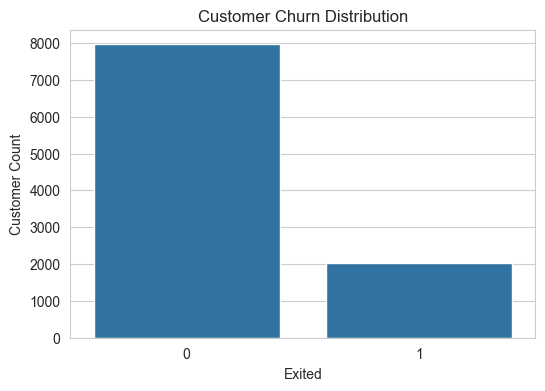

In [69]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Customer Count")

plt.show()

In [70]:
churn_rate = df['Exited'].mean()*100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


Learn
Exited = 0 → Customer stayed

Exited = 1 → Customer left

Churn Rate Formula:

Total Churned Customers
----------------------- ×100
Total Customers

---
# EDA 2 — Geography vs Churn

Which country loses the most customers?

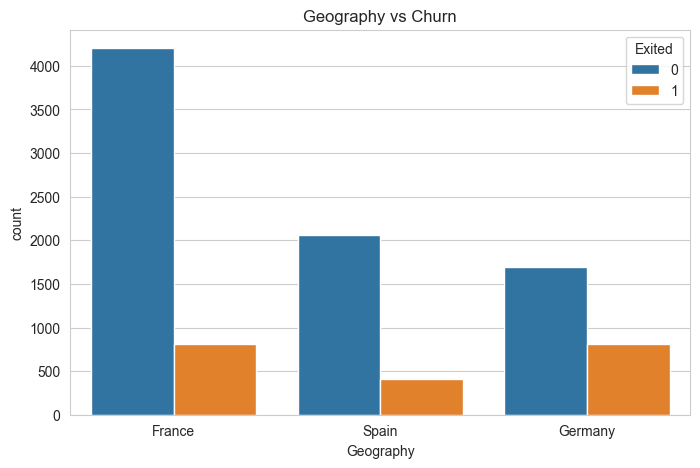

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")

plt.show()

In [72]:
geo_churn = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
) * 100

geo_churn

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


Learn

Banks operate differently across regions.

If one country has:

Higher churn

Then:

Poor service
Strong competition
Customer dissatisfaction

may exist there.

---
# EDA 3 — Age Group vs Churn

Which age segment is most likely to leave?

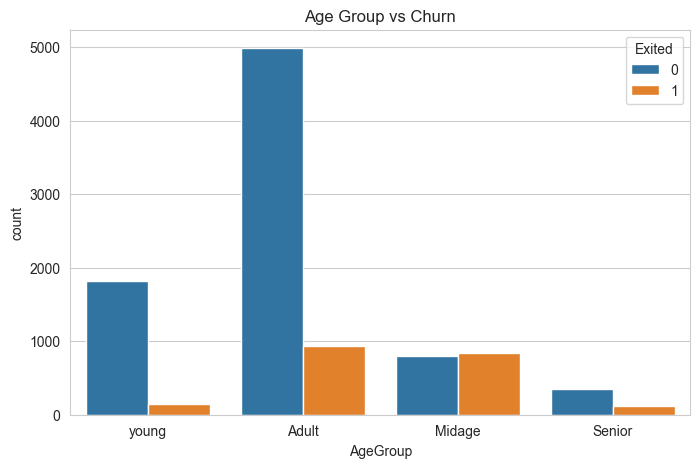

In [73]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='AgeGroup',
    hue='Exited',
    data=df
)

plt.title("Age Group vs Churn")

plt.show()

In [74]:
age_churn = pd.crosstab(
    df['AgeGroup'],
    df['Exited'],
    normalize='index'
)*100

age_churn

Exited,0,1
AgeGroup,,
young,92.479675,7.520325
Adult,84.259416,15.740584
Midage,48.876746,51.123254
Senior,75.215517,24.784483


Age is one of the strongest churn indicators.

Often:

MidAge
Senior

have higher churn than younger customers.

------------------------------
# EDA 4 — Gender vs Churn

Is churn behavior different between male and female customers?

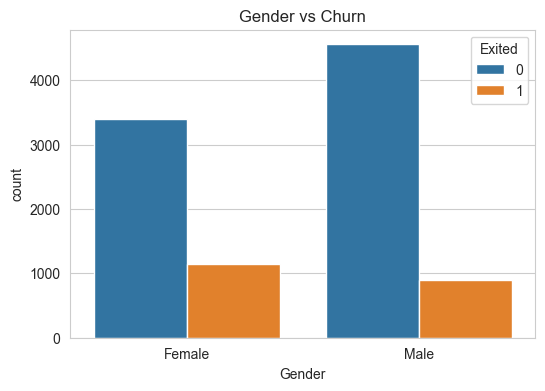

In [75]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

In [76]:
gender_churn = pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
)*100

gender_churn

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


--------------------------
# EDA 5 — Active Members vs Churn


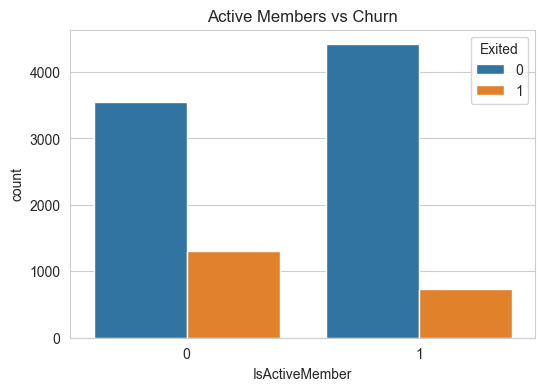

In [78]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.title("Active Members vs Churn")

plt.show()

In [79]:
active_churn = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)*100

active_churn

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


This often becomes the strongest business recommendation.

Example:

Inactive customers churn much more frequently.

----
# EDA 6 — Balance Distribution


How are customer balances distributed?

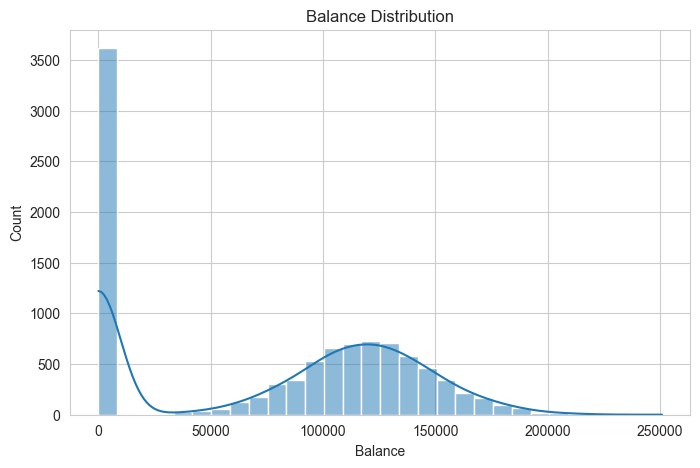

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Balance'],
    bins=30,
    kde=True
)

plt.title("Balance Distribution")

plt.show()

----
# EDA 7 — Credit Score Distribution

How financially healthy are customers?

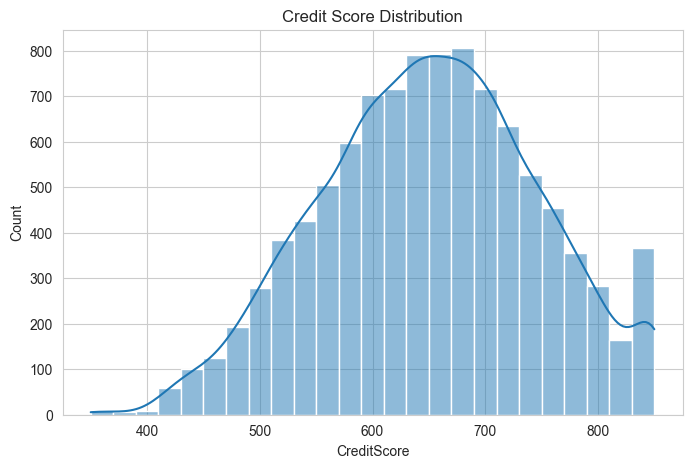

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['CreditScore'],
    bins=25,
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

----
# EDA 8 — Products vs Churn


**Objective**:
Does having more products improve customer retention?

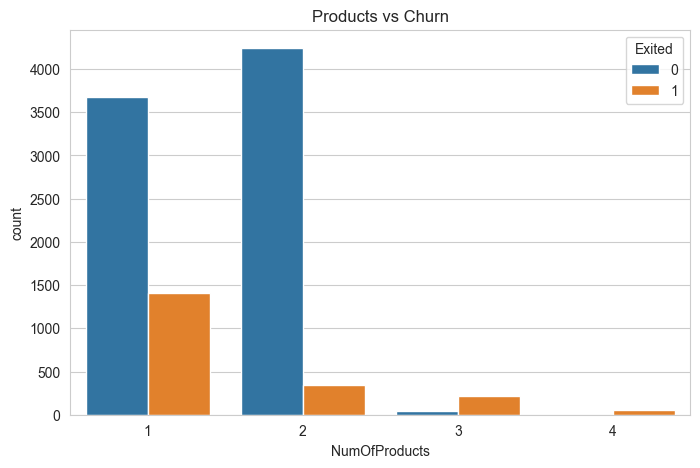

In [82]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='NumOfProducts',
    hue='Exited',
    data=df
)

plt.title("Products vs Churn")

plt.show()

In [83]:
product_churn = pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
)*100

product_churn

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


----
# EDA 9 — Revenue Risk Analysis

__Objective__ : How much balance is associated with churned customers?

In [85]:
total_risk = df['RevenueRisk'].sum()/10000000

print(
    f"Total Revenue Risk: {total_risk:,.2f} crores"
)

Total Revenue Risk: 18.56 crores


---
# EDA 10 — Correlation Heatmap

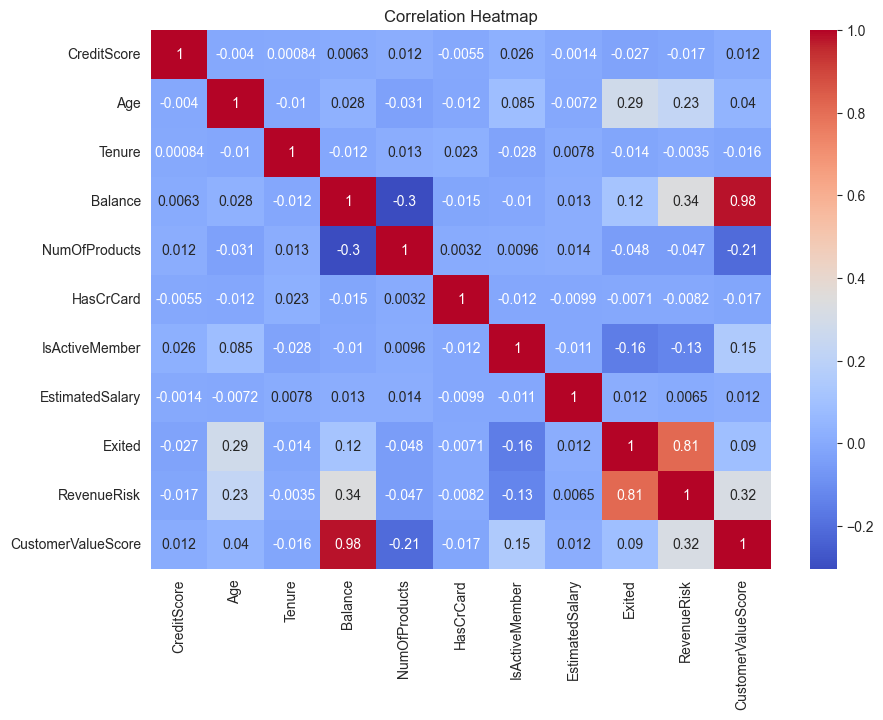

In [86]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

---
# Business Insights Summary
---
## Key Findings

- **Customer churn rate** stands at **20.37%**.
- **Germany** recorded the **highest churn rate**.
- **Mid-age customers** represent the **highest-risk segment**.
- Female Customers churned **more** .
- **Inactive customers** are significantly more likely to churn.
- Customers with **multiple products** show **better retention**.
- **High-balance churned customers** contribute substantially to **revenue risk**.

## Strategic Recommendations

**1. Improve Customer Engagement**
- Increase engagement efforts for inactive customers through personalized communication, offers, and loyalty programs.
**2. Prioritize High-Value Customers**
- Focus retention strategies on high-balance customers to minimize potential revenue loss.
**3. Address Regional Churn**
- Strengthen customer experience and support in geographies with higher churn rates.
**4. Expand Cross-Selling Initiatives**
- Encourage customers to adopt multiple products, as multi-product customers demonstrate stronger retention.
**5. Target High-Risk Age Segments**
- Develop tailored marketing and retention campaigns for age groups exhibiting the highest churn risk.
